# Notebook 12 — Survival Analysis

Survival analysis handles the 991 right-censored (stuck) cases that Notebooks 07–11 excluded.

**Setup:**
- **Event** = case reaches a terminal activity (anything other than `Send Reminder` as the last event)
- **Duration** = days from first to last event for completed cases; days from first event to observation end for stuck cases
- **Censored** = stuck cases — we know they lasted ≥ X days but never completed during the observation window

**Techniques:**
1. **Kaplan-Meier** — non-parametric survival curves overall and by group
2. **Log-rank tests** — statistical group comparisons
3. **Cox Proportional Hazards** — semi-parametric model with prefix features; hazard ratios + concordance index

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings('ignore')
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test

ROOT = Path.cwd().parent
T    = ROOT / 'outputs' / 'tables'
OUT  = ROOT / 'outputs' / 'figures'
RANDOM_STATE = 42

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

In [2]:
from src.load_event_log import load_xes_log

log = load_xes_log(ROOT / 'data' / 'raw' / 'PermitLog.xes', legacy=True)
rows = []
for trace in log:
    cid    = trace.attributes.get('concept:name', '')
    dept   = trace.attributes.get('case:OrganizationalEntity', '')
    budget = trace.attributes.get('case:RequestedBudget', np.nan)
    for evt in trace:
        rows.append({
            'case_id':   cid,
            'activity':  str(evt['concept:name']),
            'timestamp': evt['time:timestamp'],
            'org':       str(evt.get('org:resource', '')),
            'dept':      dept,
            'budget':    budget,
        })

df = pd.DataFrame(rows)
df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True).dt.tz_localize(None)
df = df.sort_values(['case_id', 'timestamp']).reset_index(drop=True)

# Observation end = last timestamp in the entire dataset
OBS_END = df['timestamp'].max()
print(f'Observation window: {df["timestamp"].min().date()} → {OBS_END.date()}')
print(f'{df["case_id"].nunique():,} cases  |  {len(df):,} events')

parsing log, completed traces ::   0%|          | 0/7065 [00:00<?, ?it/s]

parsing log, completed traces ::  15%|█▍        | 1055/7065 [00:00<00:00, 10540.81it/s]

parsing log, completed traces ::  30%|██▉       | 2110/7065 [00:00<00:00, 7725.67it/s] 

parsing log, completed traces ::  42%|████▏     | 2989/7065 [00:00<00:00, 8129.91it/s]

parsing log, completed traces ::  55%|█████▍    | 3865/7065 [00:00<00:00, 8351.88it/s]

parsing log, completed traces ::  68%|██████▊   | 4789/7065 [00:00<00:00, 8648.51it/s]

parsing log, completed traces ::  80%|████████  | 5679/7065 [00:00<00:00, 8727.56it/s]

parsing log, completed traces ::  95%|█████████▌| 6729/7065 [00:00<00:00, 9287.71it/s]

parsing log, completed traces :: 100%|██████████| 7065/7065 [00:00<00:00, 8979.37it/s]

Observation window: 2016-10-05 → 2021-09-01
7,065 cases  |  86,581 events


In [3]:
# Build survival dataset — one row per case
case_grp   = df.groupby('case_id')
case_start = case_grp['timestamp'].min()
case_end   = case_grp['timestamp'].max()
last_act   = case_grp['activity'].last()
first_dept = case_grp['dept'].first()
first_budg = case_grp['budget'].first()
n_events   = case_grp.size()

# A case is completed (event_observed=True) if its last activity is NOT Send Reminder
# Stuck cases are censored: duration = case_start → OBS_END
completed    = last_act != 'Send Reminder'
duration_raw = (case_end - case_start).dt.total_seconds() / 86400

surv = pd.DataFrame({
    'case_id':        case_start.index,
    'duration':       np.where(completed, duration_raw,
                               (OBS_END - case_start).dt.total_seconds() / 86400),
    'event_observed': completed.astype(int),
    'dept':           first_dept,
    'budget':         first_budg,
    'n_events':       n_events,
    'last_activity':  last_act,
}).reset_index(drop=True)

# Floor duration at 0.01 (lifelines requires > 0)
surv['duration'] = surv['duration'].clip(lower=0.01)

n_total    = len(surv)
n_censored = (~surv['event_observed'].astype(bool)).sum()
n_complete = surv['event_observed'].sum()

print(f'Total cases:    {n_total:,}')
print(f'Completed:      {n_complete:,}  ({n_complete/n_total:.1%})')
print(f'Censored:       {n_censored:,}  ({n_censored/n_total:.1%})')
print(f'\nDuration — completed  median={surv.loc[surv.event_observed==1,"duration"].median():.1f}d')
print(f'Duration — censored   median={surv.loc[surv.event_observed==0,"duration"].median():.1f}d')

Total cases:    7,065
Completed:      6,074  (86.0%)
Censored:       991  (14.0%)

Duration — completed  median=63.2d
Duration — censored   median=1194.4d


## 1. Kaplan-Meier — overall + by group

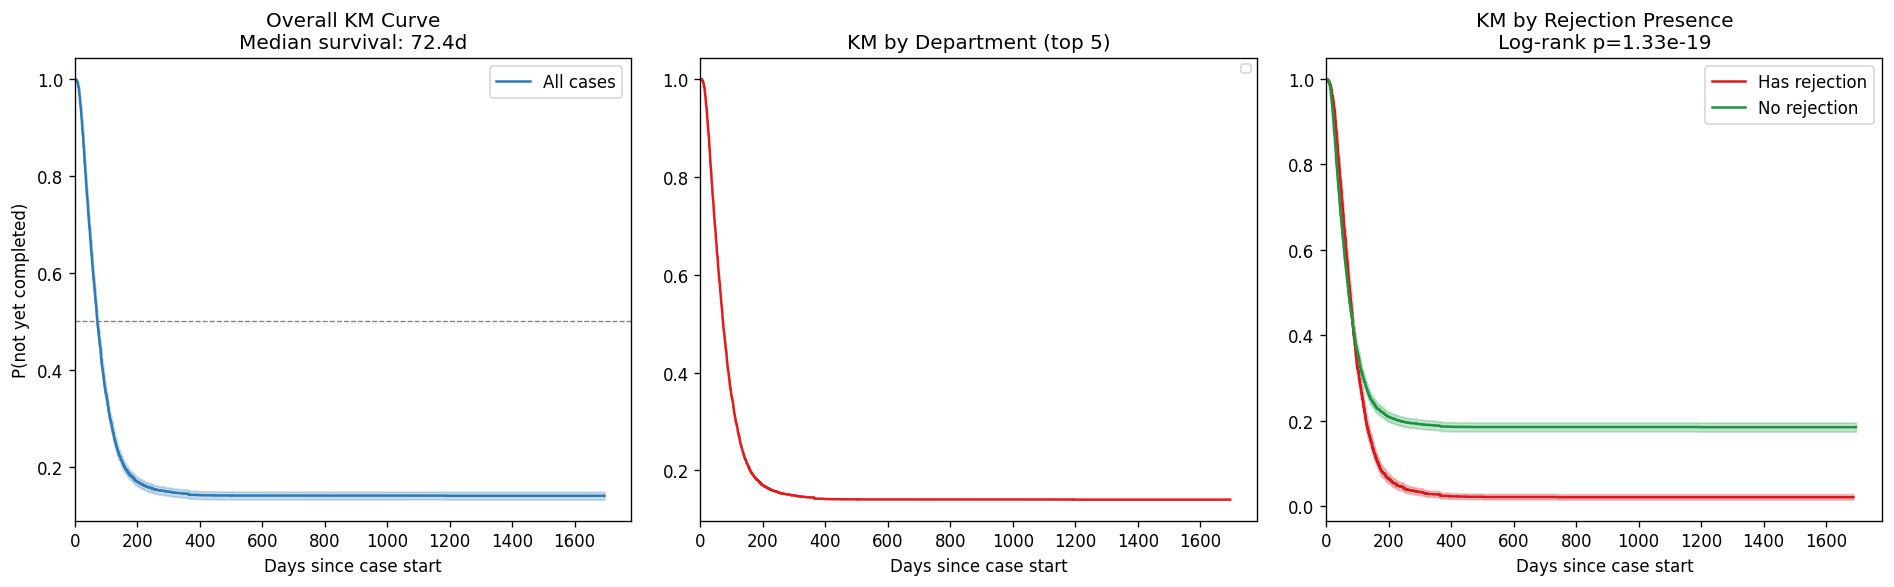

Overall median survival: 72.4d
Log-rank p (rejection vs no rejection): 1.33e-19


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Overall KM ────────────────────────────────────────────────────────────
kmf = KaplanMeierFitter()
kmf.fit(surv['duration'], event_observed=surv['event_observed'], label='All cases')
kmf.plot_survival_function(ax=axes[0], ci_show=True, color='#2c7bb6')
axes[0].axhline(0.5, color='grey', linestyle='--', linewidth=0.8)
med = kmf.median_survival_time_
axes[0].set_title(f'Overall KM Curve\nMedian survival: {med:.1f}d')
axes[0].set_xlabel('Days since case start')
axes[0].set_ylabel('P(not yet completed)')
axes[0].set_xlim(0)

# ── By department (top 5) ─────────────────────────────────────────────────
top_depts = surv['dept'].value_counts().head(5).index
colors_d  = plt.cm.Set1(np.linspace(0, 0.8, 5))
for dept, col in zip(top_depts, colors_d):
    mask = surv['dept'] == dept
    kmf_d = KaplanMeierFitter()
    kmf_d.fit(surv.loc[mask, 'duration'],
              event_observed=surv.loc[mask, 'event_observed'],
              label=str(dept)[:20])
    kmf_d.plot_survival_function(ax=axes[1], ci_show=False, color=col)
axes[1].set_title('KM by Department (top 5)')
axes[1].set_xlabel('Days since case start')
axes[1].set_ylabel('')
axes[1].set_xlim(0)
axes[1].legend(fontsize=7)

# ── By rejection presence ─────────────────────────────────────────────────
surv['has_rejection'] = df[df['activity'].str.contains('REJECTED')].groupby('case_id').size().reindex(surv['case_id']).fillna(0).gt(0).values

for has_rej, label, col in [(True, 'Has rejection', '#d7191c'), (False, 'No rejection', '#1a9641')]:
    mask = surv['has_rejection'] == has_rej
    kmf_r = KaplanMeierFitter()
    kmf_r.fit(surv.loc[mask, 'duration'],
              event_observed=surv.loc[mask, 'event_observed'],
              label=label)
    kmf_r.plot_survival_function(ax=axes[2], ci_show=True, color=col)

lr = logrank_test(
    surv.loc[surv['has_rejection'], 'duration'],
    surv.loc[~surv['has_rejection'], 'duration'],
    event_observed_A=surv.loc[surv['has_rejection'], 'event_observed'],
    event_observed_B=surv.loc[~surv['has_rejection'], 'event_observed'],
)
axes[2].set_title(f'KM by Rejection Presence\nLog-rank p={lr.p_value:.2e}')
axes[2].set_xlabel('Days since case start')
axes[2].set_ylabel('')
axes[2].set_xlim(0)

plt.tight_layout()
fig.savefig(OUT / 'survival_km_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Overall median survival: {med:.1f}d')
print(f'Log-rank p (rejection vs no rejection): {lr.p_value:.2e}')

In [5]:
# Log-rank tests across all departments
dept_lr = multivariate_logrank_test(surv['duration'], surv['dept'],
                                     event_observed=surv['event_observed'])

# Per-department median survival times
dept_stats = []
for dept in surv['dept'].unique():
    mask = surv['dept'] == dept
    kmf_d = KaplanMeierFitter()
    kmf_d.fit(surv.loc[mask, 'duration'],
              event_observed=surv.loc[mask, 'event_observed'])
    n       = mask.sum()
    n_cens  = (~surv.loc[mask, 'event_observed'].astype(bool)).sum()
    dept_stats.append({
        'department':     dept,
        'n_cases':        n,
        'n_censored':     n_cens,
        'censoring_rate': n_cens / n,
        'median_survival_days': kmf_d.median_survival_time_,
    })

dept_surv_df = pd.DataFrame(dept_stats).sort_values('median_survival_days')
dept_surv_df.to_csv(T / 'survival_by_department.csv', index=False)

print(f'Multivariate log-rank across departments: p={dept_lr.p_value:.2e}')
print()
print(dept_surv_df.to_string(index=False))

Multivariate log-rank across departments: p=nan

department  n_cases  n_censored  censoring_rate  median_survival_days
               7065         991        0.140269             72.381921


## 2. Cox Proportional Hazards — prefix features

In [6]:
PREFIX_K = 8

ACTS = [
    'Send Reminder', 'Declaration REJECTED by DIRECTOR',
    'Declaration REJECTED by EMPLOYEE', 'Declaration REJECTED by BUDGET OWNER',
    'Permit REJECTED by ADMINISTRATION', 'Permit REJECTED by BUDGET OWNER',
    'Permit REJECTED by PRE_APPROVER', 'Permit REJECTED by DIRECTOR',
    'Permit REJECTED by MISSING', 'Declaration APPROVED by DIRECTOR',
    'Declaration APPROVED by BUDGET OWNER', 'Declaration APPROVED by SUPERVISOR',
    'Permit APPROVED by BUDGET OWNER', 'Permit APPROVED by PRE_APPROVER',
    'Permit FINAL_APPROVED by SUPERVISOR',
]
flag_cols = [f"has_{a.replace(' ','_').replace(':','_')}" for a in ACTS]
act_enc   = LabelEncoder().fit(df['activity'])

prefix_rows = []
for cid, grp in df.groupby('case_id'):
    prefix  = grp.head(PREFIX_K)
    t0      = prefix['timestamp'].iloc[0]
    t_last  = prefix['timestamp'].iloc[-1]
    elapsed = (t_last - t0).total_seconds() / 86400
    acts_in = set(prefix['activity'])
    row = {
        'case_id':          cid,
        'elapsed_days':     elapsed,
        'n_events_prefix':  len(prefix),
        'n_rejections':     prefix['activity'].str.contains('REJECTED').sum(),
        'n_reminders':      (prefix['activity'] == 'Send Reminder').sum(),
        'n_approvals':      prefix['activity'].str.contains('APPROVED').sum(),
        'first_act_enc':    act_enc.transform([prefix['activity'].iloc[0]])[0],
        'last_act_enc':     act_enc.transform([prefix['activity'].iloc[-1]])[0],
        'budget':           prefix['budget'].iloc[0],
        'case_start_month': t0.month,
        'case_start_dow':   t0.dayofweek,
    }
    for act, col in zip(ACTS, flag_cols):
        row[col] = int(act in acts_in)
    prefix_rows.append(row)

prefix_df = pd.DataFrame(prefix_rows)

# Merge with survival data
cox_df = surv[['case_id', 'duration', 'event_observed']].merge(prefix_df, on='case_id')

FEAT_COLS = ['elapsed_days', 'n_events_prefix', 'n_rejections', 'n_reminders',
             'n_approvals', 'first_act_enc', 'last_act_enc',
             'budget', 'case_start_month', 'case_start_dow'] + flag_cols

# Drop all-NaN columns, impute, then drop near-zero-variance columns
# (Cox PH Hessian becomes singular when a binary feature is nearly always 0 or 1)
X_cox = cox_df[FEAT_COLS].copy()
X_cox = X_cox.drop(columns=[c for c in X_cox.columns if X_cox[c].isna().all()])
imp = SimpleImputer(strategy='median')
X_cox_imp = pd.DataFrame(imp.fit_transform(X_cox), columns=X_cox.columns)

MIN_VARIANCE = 0.01   # drop columns where >99% of rows share the same value
var_mask      = X_cox_imp.var() >= MIN_VARIANCE
dropped       = X_cox_imp.columns[~var_mask].tolist()
X_cox_imp     = X_cox_imp.loc[:, var_mask]
feat_cols_cox = X_cox_imp.columns.tolist()

print(f'Dropped {len(dropped)} near-constant features: {dropped}')
print(f'Remaining features: {len(feat_cols_cox)}')

cox_input = X_cox_imp.copy()
cox_input['duration']       = cox_df['duration'].values
cox_input['event_observed'] = cox_df['event_observed'].values

print(f'Cox input shape: {cox_input.shape}')

Dropped 8 near-constant features: ['has_Declaration_REJECTED_by_DIRECTOR', 'has_Declaration_REJECTED_by_BUDGET_OWNER', 'has_Permit_REJECTED_by_BUDGET_OWNER', 'has_Permit_REJECTED_by_PRE_APPROVER', 'has_Permit_REJECTED_by_DIRECTOR', 'has_Permit_REJECTED_by_MISSING', 'has_Declaration_APPROVED_by_DIRECTOR', 'has_Declaration_APPROVED_by_SUPERVISOR']
Remaining features: 16
Cox input shape: (7065, 18)


In [7]:
cph = CoxPHFitter(penalizer=1.0)   # higher penalizer regularises correlated binary flags
cph.fit(cox_input, duration_col='duration', event_col='event_observed')

print(f'Concordance index: {cph.concordance_index_:.3f}')
print(f'Log-likelihood ratio test p: {cph.log_likelihood_ratio_test().p_value:.2e}')
print()
cph.print_summary(decimals=3, columns=['coef', 'exp(coef)', 'se(coef)', 'z', 'p'])

Concordance index: 0.814
Log-likelihood ratio test p: 0.00e+00



<lifelines.CoxPHFitter: fitted with 7065 total observations, 991 right-censored observations>
             duration col = 'duration'
                event col = 'event_observed'
                penalizer = 1.0
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 7065
number of events observed = 6074
   partial log-likelihood = -47903.602
         time fit was run = 2026-06-26 23:05:09 UTC

---
                                           coef exp(coef)  se(coef)       z       p
covariate                                                                          
elapsed_days                             -0.004     0.996     0.000 -28.035 <0.0005
n_events_prefix                           0.026     1.026     0.014   1.860   0.063
n_rejections                             -0.009     0.991     0.013  -0.693   0.488
n_reminders                              -0.285     0.752     0.016 -17.873 <0.0005
n_approvals                              -0.012     0.988     0.009  -1.468   0.142
first_act_enc                             0.011     1.011     0.002   6.038 <0.0005
last_act_enc                             -0.014     0.986     0.001 -26.317 <0.0005
case_start_month                          0.011     1.012     0.003   4.202 <0.0005
case_start_dow                           -0.001     0.999     0.005  -0.126   0.900
has_Send_Reminder                        -0.426     0.653     0.027 -15.572 <0.0005
has_Declaration_REJECTED_by_EMPLOYEE      0.084     1.088     0.036   2.342   0.019
has_Permit_REJECTED_by_ADMINISTRATION     0.013     1.014     0.066   0.203   0.839
has_Declaration_APPROVED_by_BUDGET_OWNER -0.130     0.878     0.078  -1.665   0.096
has_Permit_APPROVED_by_BUDGET_OWNER      -0.035     0.965     0.020  -1.789   0.074
has_Permit_APPROVED_by_PRE_APPROVER      -0.033     0.968     0.032  -1.038   0.299
has_Permit_FINAL_APPROVED_by_SUPERVISOR   0.082     1.086     0.026   3.162   0.002
---
Concordance = 0.814
Partial AIC = 95839.204
log-likelihood ratio test = 3605.043 on 16 df
-log2(p) of ll-ratio test = inf

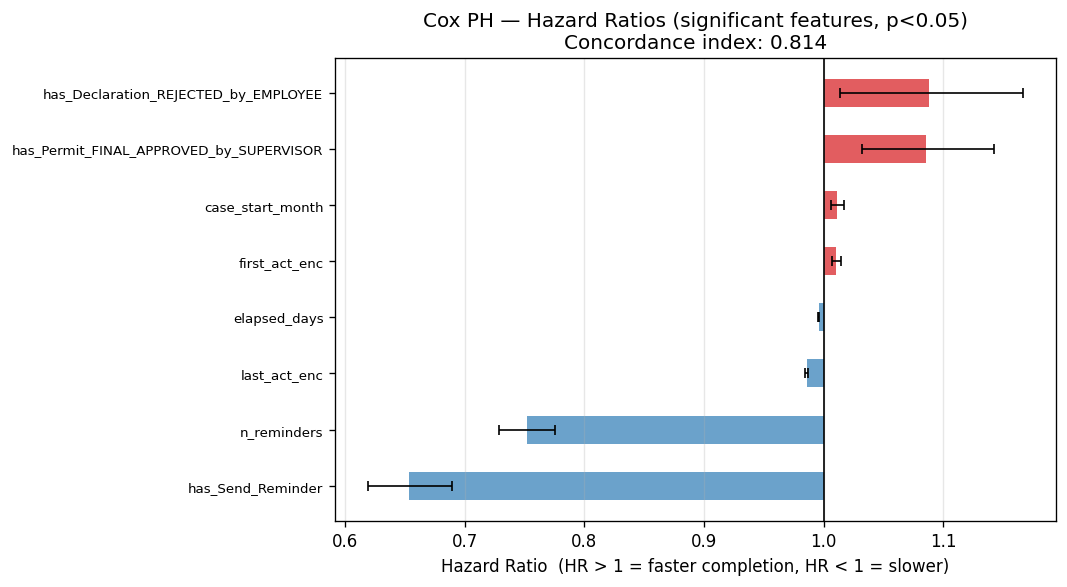

Saved survival_cox_hazard_ratios.png + .csv


In [8]:
# Hazard ratio forest plot — top significant features
hr_df = cph.summary[['coef', 'exp(coef)', 'exp(coef) lower 95%', 'exp(coef) upper 95%', 'p']].copy()
hr_df.columns = ['coef', 'HR', 'HR_lo', 'HR_hi', 'p']
hr_df = hr_df.sort_values('coef')

# Filter: p < 0.05 or abs(coef) largest
sig = hr_df[hr_df['p'] < 0.05].copy()
if len(sig) > 20:
    sig = sig.reindex(sig['coef'].abs().nlargest(20).index)
sig = sig.sort_values('coef')

fig, ax = plt.subplots(figsize=(9, max(5, len(sig) * 0.4)))
y_pos = np.arange(len(sig))
ax.barh(y_pos, sig['HR'] - 1, left=1, height=0.5,
        color=['#d7191c' if h > 1 else '#2c7bb6' for h in sig['HR']], alpha=0.7)
ax.errorbar(sig['HR'], y_pos,
            xerr=[sig['HR'] - sig['HR_lo'], sig['HR_hi'] - sig['HR']],
            fmt='none', color='black', capsize=3, linewidth=1)
ax.axvline(1, color='black', linewidth=1)
ax.set_yticks(y_pos)
ax.set_yticklabels(sig.index, fontsize=8)
ax.set_xlabel('Hazard Ratio  (HR > 1 = faster completion, HR < 1 = slower)')
ax.set_title(f'Cox PH — Hazard Ratios (significant features, p<0.05)\nConcordance index: {cph.concordance_index_:.3f}')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
fig.savefig(OUT / 'survival_cox_hazard_ratios.png', dpi=150, bbox_inches='tight')
plt.show()

hr_df.to_csv(T / 'survival_cox_hazard_ratios.csv')
print('Saved survival_cox_hazard_ratios.png + .csv')

## 3. Survival curves by risk group (Cox-stratified)

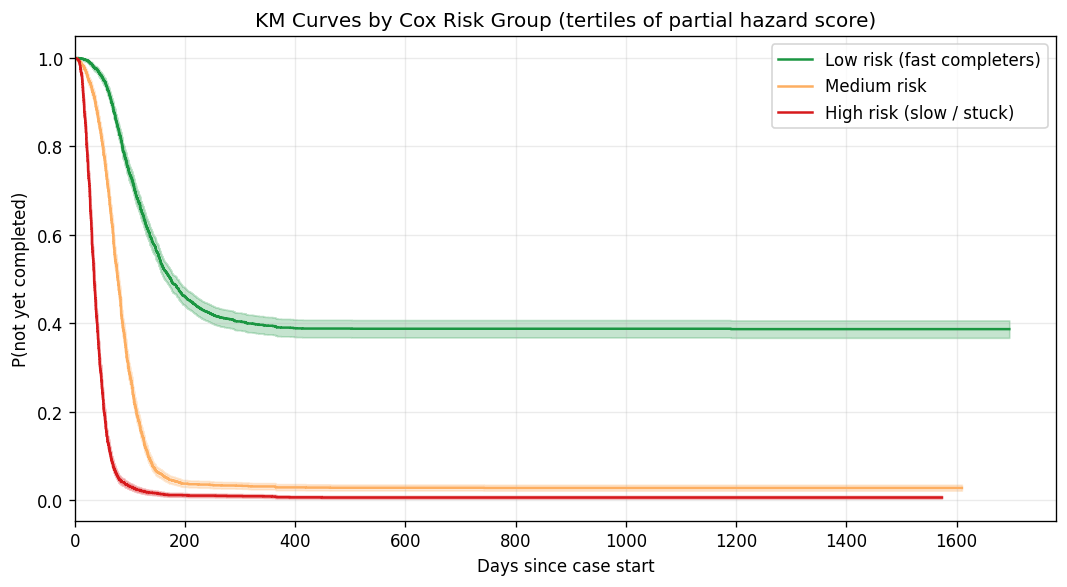

Low risk (fast completers): n=2355  censoring=38.7%  median=174d
Medium risk: n=2355  censoring=2.8%  median=78d
High risk (slow / stuck): n=2355  censoring=0.6%  median=35d


In [9]:
# Partition cases into low / medium / high risk using Cox partial hazard score
risk_scores = cph.predict_partial_hazard(cox_input)
cox_df_plot = cox_df[['duration', 'event_observed']].copy()
cox_df_plot['risk_score'] = risk_scores.values

tertiles = cox_df_plot['risk_score'].quantile([1/3, 2/3])
def risk_group(s):
    if s <= tertiles.iloc[0]:
        return 'Low risk (fast completers)'
    elif s <= tertiles.iloc[1]:
        return 'Medium risk'
    else:
        return 'High risk (slow / stuck)'
cox_df_plot['risk_group'] = cox_df_plot['risk_score'].apply(risk_group)

fig, ax = plt.subplots(figsize=(9, 5))
colors_rg = {'Low risk (fast completers)': '#1a9641',
             'Medium risk':                '#fdae61',
             'High risk (slow / stuck)':   '#d7191c'}
for grp, col in colors_rg.items():
    mask = cox_df_plot['risk_group'] == grp
    kmf_g = KaplanMeierFitter()
    kmf_g.fit(cox_df_plot.loc[mask, 'duration'],
              event_observed=cox_df_plot.loc[mask, 'event_observed'],
              label=grp)
    kmf_g.plot_survival_function(ax=ax, ci_show=True, color=col)

ax.set_title('KM Curves by Cox Risk Group (tertiles of partial hazard score)')
ax.set_xlabel('Days since case start')
ax.set_ylabel('P(not yet completed)')
ax.set_xlim(0)
ax.grid(alpha=0.25)
plt.tight_layout()
fig.savefig(OUT / 'survival_km_risk_groups.png', dpi=150, bbox_inches='tight')
plt.show()

# Median survival per group
for grp in ['Low risk (fast completers)', 'Medium risk', 'High risk (slow / stuck)']:
    mask = cox_df_plot['risk_group'] == grp
    kmf_g = KaplanMeierFitter()
    kmf_g.fit(cox_df_plot.loc[mask,'duration'],
              event_observed=cox_df_plot.loc[mask,'event_observed'])
    cens_pct = (~cox_df_plot.loc[mask,'event_observed'].astype(bool)).mean()
    print(f'{grp}: n={mask.sum()}  censoring={cens_pct:.1%}  median={kmf_g.median_survival_time_:.0f}d')

## 4. Summary and save

In [10]:
import joblib

# Save Cox model bundle
cox_bundle = {
    'model':            cph,
    'imputer':          imp,
    'feature_cols':     feat_cols_cox,
    'concordance_idx':  round(cph.concordance_index_, 3),
    'n_cases':          n_total,
    'n_censored':       int(n_censored),
    'censoring_rate':   round(n_censored / n_total, 3),
    'median_survival':  round(float(med), 1),
    'note':             'elapsed_days included; all 7065 cases; stuck=censored',
}
joblib.dump(cox_bundle, ROOT / 'app' / 'model' / 'survival_cox_k8.joblib')
print(f'Saved survival_cox_k8.joblib')

# Summary table
summary = pd.DataFrame([{
    'n_total':            n_total,
    'n_completed':        int(n_complete),
    'n_censored':         int(n_censored),
    'censoring_rate':     f'{n_censored/n_total:.1%}',
    'km_median_survival': f'{med:.1f}d',
    'cox_concordance':    f'{cph.concordance_index_:.3f}',
    'dept_logrank_p':     f'{dept_lr.p_value:.2e}',
    'rejection_logrank_p': f'{lr.p_value:.2e}',
}])
summary.to_csv(T / 'survival_summary.csv', index=False)
print('\nSummary:')
print(summary.T.to_string(header=False))

Saved survival_cox_k8.joblib

Summary:
n_total                  7065
n_completed              6074
n_censored                991
censoring_rate          14.0%
km_median_survival      72.4d
cox_concordance         0.814
dept_logrank_p            nan
rejection_logrank_p  1.33e-19
